# ReLU activation in a pair of neurons — NNFS Chapter 4

Here we explore **how a barely nonlinear activation like ReLU can still create nonlinear functions**, 
especially when we start chaining neurons.

We’ll work with the rectified linear activation function:

$$\text{ReLU}(x) = \max(0, x)$$

For a single neuron with one input:

- Pre-activation: $z = w x + b$
- Activation: $y = \text{ReLU}(z)$

We’ll:

1. Look at a single ReLU neuron with different weights and biases.
2. See how the **bias** shifts the activation point horizontally.
3. Flip the weight negative and see how that changes the behavior.
4. Chain **two ReLU neurons** (a tiny 2-layer network with 1 neuron per layer) and see how this creates
   a function with both an **activation** and **deactivation** point.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def setup_axes(title=None, xlim=(-1, 1), ylim=(-1, 1)):
    """Set up axes to look roughly like the book diagrams."""
    plt.axhline(0, color="tab:blue", alpha=0.3, linewidth=1)
    plt.axvline(0, color="tab:blue", alpha=0.3, linewidth=1)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    if title is not None:
        plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)

def neuron_output(x, w, b):
    """Single-input ReLU neuron: y = ReLU(w * x + b)."""
    z = w * x + b
    return relu(z)

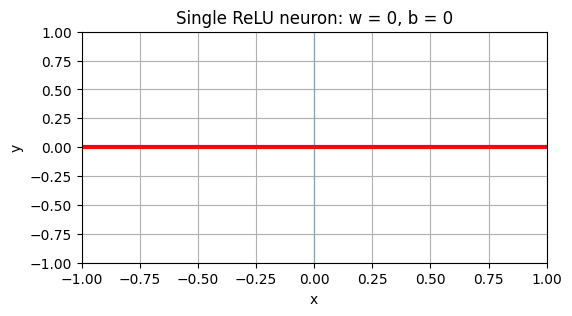

In [2]:
# 1. Single ReLU neuron: w = 0, b = 0

x = np.linspace(-1, 1, 400)
w0, b0 = 0.0, 0.0
y0 = neuron_output(x, w0, b0)

plt.figure(figsize=(6, 3))
plt.plot(x, y0, color="red", linewidth=3)
setup_axes("Single ReLU neuron: w = 0, b = 0", xlim=(-1, 1), ylim=(-1, 1))
plt.show()

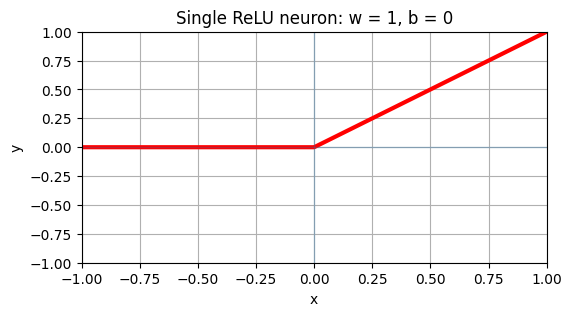

In [3]:
# 2. Single ReLU neuron: w = 1, b = 0  (basic ReLU: y = max(0, x))

w1, b1 = 1.0, 0.0
y1 = neuron_output(x, w1, b1)

plt.figure(figsize=(6, 3))
plt.plot(x, y1, color="red", linewidth=3)
setup_axes("Single ReLU neuron: w = 1, b = 0", xlim=(-1, 1), ylim=(-1, 1))
plt.show()

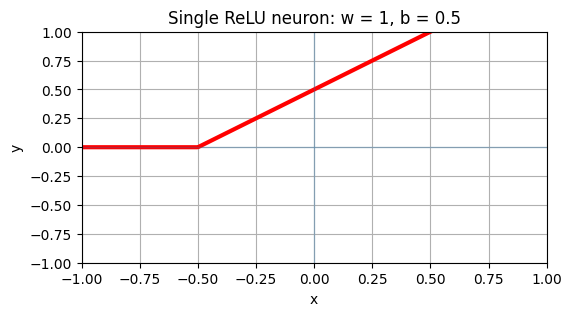

In [4]:
# 3. Single ReLU neuron: w = 1, b = 0.5  (bias shifts activation point)

w2, b2 = 1.0, 0.5
y2 = neuron_output(x, w2, b2)

plt.figure(figsize=(6, 3))
plt.plot(x, y2, color="red", linewidth=3)
setup_axes("Single ReLU neuron: w = 1, b = 0.5", xlim=(-1, 1), ylim=(-1, 1))
plt.show()

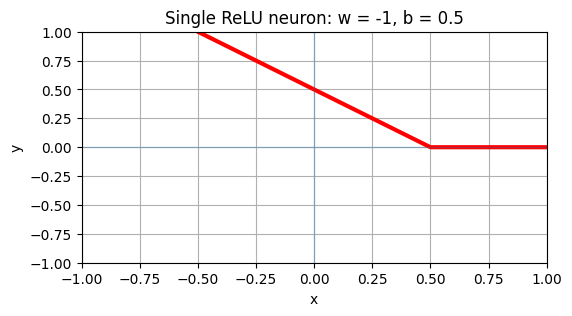

In [5]:
# 4. Single ReLU neuron: w = -1, b = 0.5  (neuron deactivates after a point)

w3, b3 = -1.0, 0.5
y3 = neuron_output(x, w3, b3)

plt.figure(figsize=(6, 3))
plt.plot(x, y3, color="red", linewidth=3)
setup_axes("Single ReLU neuron: w = -1, b = 0.5", xlim=(-1, 1), ylim=(-1, 1))
plt.show()

## Two ReLU neurons in a chain

Now let’s treat this as a tiny network with **2 hidden layers of 1 neuron each**:

- First neuron: $y_1 = \text{ReLU}(w_1 x + b_1)$  
- Second neuron: $y_2 = \text{ReLU}(w_2 y_1 + b_2)$

Together this gives us:

$$f(x) = \text{ReLU}\bigl(w_2 \, \text{ReLU}(w_1 x + b_1) + b_2\bigr)$$

We’ll start with the parameters from the last single-neuron example for the first neuron:

- $w_1 = -1.0$
- $b_1 = 0.5$

and then play with $w_2$ and $b_2$ for the second neuron.


In [6]:
def two_relu_neurons(x, w1, b1, w2, b2):
    y1 = neuron_output(x, w1, b1)
    y2 = neuron_output(y1, w2, b2)
    return y1, y2

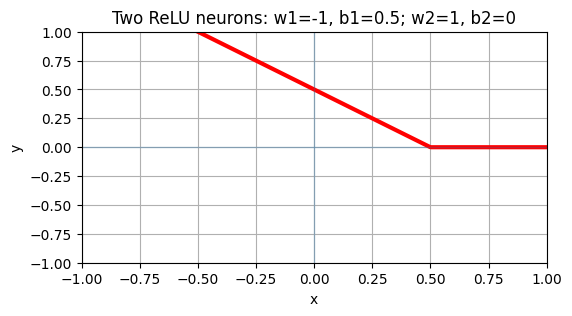

In [7]:
# 5. Pair of neurons: second neuron w2 = 1, b2 = 0

w1, b1 = -1.0, 0.5
w2, b2 = 1.0, 0.0

y1_1, y2_1 = two_relu_neurons(x, w1, b1, w2, b2)

plt.figure(figsize=(6, 3))
plt.plot(x, y2_1, color="red", linewidth=3)
setup_axes("Two ReLU neurons: w1=-1, b1=0.5; w2=1, b2=0", xlim=(-1, 1), ylim=(-1, 1))
plt.show()

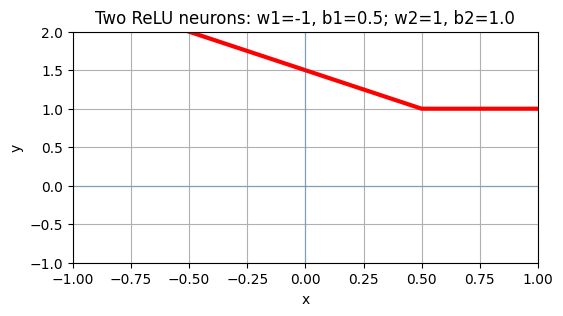

In [8]:
# 6. Pair of neurons: adjust second bias (vertical shift)

w1, b1 = -1.0, 0.5
w2, b2 = 1.0, 1.0   # add positive bias to the second neuron

y1_2, y2_2 = two_relu_neurons(x, w1, b1, w2, b2)

plt.figure(figsize=(6, 3))
plt.plot(x, y2_2, color="red", linewidth=3)
setup_axes("Two ReLU neurons: w1=-1, b1=0.5; w2=1, b2=1.0", xlim=(-1, 1), ylim=(-1, 2))
plt.show()

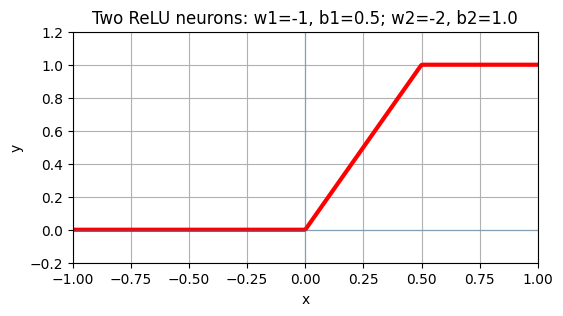

In [9]:
# 7. Pair of neurons: second weight negative (activation + deactivation region)

w1, b1 = -1.0, 0.5
w2, b2 = -2.0, 1.0

y1_3, y2_3 = two_relu_neurons(x, w1, b1, w2, b2)

plt.figure(figsize=(6, 3))
plt.plot(x, y2_3, color="red", linewidth=3)
setup_axes("Two ReLU neurons: w1=-1, b1=0.5; w2=-2, b2=1.0", xlim=(-1, 1), ylim=(-0.2, 1.2))
plt.show()

In this last case, the composed function

$$f(x) = \text{ReLU}\bigl(-2 \, \text{ReLU}(-x + 0.5) + 1\bigr)$$

has:

- A region where the output is **zero** (both neurons inactive or only the second active with clipped output),
- A region where the output is **changing** (both neurons “active”), and
- A region where the output becomes **constant again** (the second neuron deactivates).

That “active window” is exactly the kind of nonlinear behavior we need to build rich functions by
combining many such neurons.

---

## Adding the original book diagrams

To include the original NNFS figures in this notebook:

1. Save the PNGs into a folder beside this notebook, for example:

```text
notebooks/nnfs/chapter_4/
    07_relu_activation_pair_of_neurons.ipynb
    img/
      fig_4_12_single_relu_zero.png
      fig_4_13_single_relu_basic.png
      fig_4_14_single_relu_bias.png
      fig_4_15_single_relu_negative_weight.png
      fig_4_16_two_neurons_basic.png
      fig_4_17_two_neurons_bias2.png
      fig_4_18_two_neurons_negative_weight2.png
```

2. Use Markdown cells with standard Jupyter image syntax, for example:

```markdown
![Fig 4.12 – single ReLU neuron, w=0, b=0](img/fig_4_12_single_relu_zero.png)

![Fig 4.13 – single ReLU neuron, w=1, b=0](img/fig_4_13_single_relu_basic.png)

![Fig 4.14 – single ReLU neuron, w=1, b=0.5](img/fig_4_14_single_relu_bias.png)

![Fig 4.15 – single ReLU neuron, w=-1, b=0.5](img/fig_4_15_single_relu_negative_weight.png)
```

All the math in this notebook uses `$...$` / `$$...$$` so Jupyter will render it correctly.
